# DATA266 Task 3 CycleGAN Image Style Transfer

This notebook implements an individual, from-scratch CycleGAN for unpaired Monet/photo translation.


The generators and discriminators are implemented manually. Pretrained or foundation models are not used for image generation or training. Standard pretrained feature extractors are used only for evaluation metrics such as FID/KID/LPIPS, and never to create submitted images.

In [28]:
# Install only evaluation dependencies if needed.
# Do not reinstall PyTorch because the GPU kernel already has a CUDA build.

%pip install -q pillow matplotlib torchvision scikit-learn scipy pandas tqdm lpips

Note: you may need to restart the kernel to use updated packages.


In [29]:
import os
import csv
import json
import math
import time
import random
import platform
import subprocess
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from tqdm.auto import tqdm

print("Imports completed.")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Imports completed.
PyTorch: 2.1.2
CUDA available: True


In [30]:
# Reproducibility, hardware, and assignment identifiers

# Single source of randomness for this run: weight initialisation, the
# train/validation split, shuffling, augmentation and KID subset sampling all
# derive from it, so the run is reproducible from this one number.
SEED = 5330

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device selection. CUDA is the target for the real training run; MPS lets the
# same notebook smoke test on an Apple Silicon laptop instead of falling back
# to CPU, where a 256x256 CycleGAN step is impractically slow.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    GPU_NAME = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    GPU_NAME = "Apple Silicon GPU (MPS)"
else:
    DEVICE = torch.device("cpu")
    GPU_NAME = "CPU"


def reset_peak_memory():
    """Reset the peak-memory counter for whichever device is active."""
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()


def peak_memory_gb():
    """Peak allocated memory in GB for the active device.

    Only CUDA reports a true peak. The MPS figure is current driver
    allocation at the moment of the call, not a high-water mark, so it
    understates the peak and must not be quoted as one in the report. Real
    peak-memory numbers come from the CUDA training run.
    """
    if DEVICE.type == "cuda":
        return torch.cuda.max_memory_allocated() / 1024 ** 3
    if DEVICE.type == "mps":
        return torch.mps.driver_allocated_memory() / 1024 ** 3
    return 0.0

print("SEED:", SEED)
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Operating system:", platform.platform())
print("Device:", DEVICE)
print("GPU:", GPU_NAME)

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
    try:
        print(subprocess.check_output(["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"], text=True))
    except Exception as exc:
        print("nvidia-smi unavailable:", exc)

SEED: 5330
Python: 3.10.13
PyTorch: 2.1.2
Operating system: Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.31
Device: cuda
GPU: NVIDIA GeForce RTX 4090
CUDA version: 12.1
GPU memory GB: 23.99
NVIDIA GeForce RTX 4090, 24564 MiB, 610.60



## 1. Dataset discovery and validation

The two domains are intentionally unpaired. Monet images and photo images are shuffled and split independently using the assignment seed.

In [31]:
# Locate the Monet and Photo image folders.
#
# No path is hard coded, so the notebook runs unchanged on a laptop, a GPU lab
# node or Colab. Resolution order:
#   1. DATA266_MONET_DIR / DATA266_PHOTO_DIR environment variables
#   2. known mount points used by the lab and by Kaggle
#   3. a recursive search downward from the working directory
#
# To point it somewhere else without editing this file:
#   export DATA266_MONET_DIR=/path/to/monet_jpg
#   export DATA266_PHOTO_DIR=/path/to/photo_jpg

import os

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Checked directly, cheapest first. Only the working directory is searched
# recursively, so this never crawls an entire shared filesystem.
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path("/app/dataset"),
    Path("/kaggle/input/gan-getting-started"),
    Path("/content/gan-getting-started"),
    Path.home() / "data",
]


def resolve_domain_dir(env_var, folder_name):
    """Return the directory holding one image domain, or explain where it looked."""
    override = os.environ.get(env_var)
    if override:
        path = Path(override).expanduser().resolve()
        if not path.is_dir():
            raise FileNotFoundError(f"{env_var}={override} is not a directory")
        return path

    searched = []
    for root in CANDIDATE_ROOTS:
        candidate = root / folder_name
        searched.append(candidate)
        if candidate.is_dir():
            return candidate.resolve()

    for found in sorted(Path.cwd().rglob(folder_name)):
        if found.is_dir():
            return found.resolve()

    raise FileNotFoundError(
        f"Could not find a '{folder_name}' directory.\n"
        f"Set {env_var} to its path, for example:\n"
        f"    os.environ['{env_var}'] = '/path/to/{folder_name}'\n"
        f"Looked in:\n" + "\n".join(f"    {p}" for p in searched)
    )


MONET_DIR = resolve_domain_dir("DATA266_MONET_DIR", "monet_jpg")
PHOTO_DIR = resolve_domain_dir("DATA266_PHOTO_DIR", "photo_jpg")

monet_images = sorted(p for p in MONET_DIR.iterdir()
                      if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
photo_images = sorted(p for p in PHOTO_DIR.iterdir()
                      if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

print("Monet directory:", MONET_DIR)
print("Photo directory:", PHOTO_DIR)
print("Monet images:", len(monet_images))
print("Photo images:", len(photo_images))

if not monet_images or not photo_images:
    raise RuntimeError("A domain resolved to a directory with no images. Check the paths above.")

Monet directory: /app/dataset/dataset/monet_jpg
Photo directory: /app/dataset/dataset/photo_jpg
Monet images: 300
Photo images: 7038


In [32]:
def inspect_images(image_paths, domain_name):
    sizes = Counter()
    modes = Counter()
    corrupted = []

    for path in image_paths:
        try:
            with Image.open(path) as image:
                image.verify()
            with Image.open(path) as image:
                sizes[image.size] += 1
                modes[image.mode] += 1
        except Exception as exc:
            corrupted.append((str(path), str(exc)))

    print(domain_name)
    print("Total images:", len(image_paths))
    print("Image sizes:", sizes.most_common(10))
    print("Image modes:", dict(modes))
    print("Corrupted images:", len(corrupted))
    if corrupted:
        print("First corrupted file:", corrupted[0])
    return sizes, modes, corrupted

monet_sizes, monet_modes, monet_corrupted = inspect_images(monet_images, "Monet")
photo_sizes, photo_modes, photo_corrupted = inspect_images(photo_images, "Photo")

Monet
Total images: 300
Image sizes: [((256, 256), 300)]
Image modes: {'RGB': 300}
Corrupted images: 0
Photo
Total images: 7038
Image sizes: [((256, 256), 7038)]
Image modes: {'RGB': 7038}
Corrupted images: 0


In [33]:
# Deterministic independent 90/10 unpaired splits

split_rng = random.Random(SEED)
monet_images = list(monet_images)
photo_images = list(photo_images)
split_rng.shuffle(monet_images)
split_rng.shuffle(photo_images)

monet_validation_count = max(1, int(len(monet_images) * 0.10))
photo_validation_count = max(1, int(len(photo_images) * 0.10))

monet_val_images = monet_images[:monet_validation_count]
monet_train_images = monet_images[monet_validation_count:]
photo_val_images = photo_images[:photo_validation_count]
photo_train_images = photo_images[photo_validation_count:]

print("Monet training images:", len(monet_train_images))
print("Monet validation images:", len(monet_val_images))
print("Photo training images:", len(photo_train_images))
print("Photo validation images:", len(photo_val_images))

Monet training images: 270
Monet validation images: 30
Photo training images: 6335
Photo validation images: 703


## 2. Unpaired data loaders

The smaller Monet domain is sampled cyclically while the epoch length is determined by the larger photo domain. Batch size 1 is standard for CycleGAN and is retained for stable image translation.

In [34]:
# Training resolution. The generators and the PatchGAN discriminators are
# fully convolutional, so the architecture is unchanged by this; only the
# spatial size of every feature map is. The Kaggle submission is scored on
# 256x256 images and my teammate trained at 256, so training at 256 keeps the
# two runs comparable and avoids an upsampling step at inference. Set
# DATA266_IMAGE_SIZE to 128 for a quick laptop smoke test, which cuts the work
# per step by roughly four.
IMAGE_SIZE = int(os.environ.get("DATA266_IMAGE_SIZE", 256))
BATCH_SIZE = 1

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

validation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class UnpairedImageDataset(Dataset):
    def __init__(self, domain_a_images, domain_b_images, transform, dataset_length=None):
        self.domain_a_images = list(domain_a_images)
        self.domain_b_images = list(domain_b_images)
        self.transform = transform
        self.dataset_length = dataset_length or max(len(self.domain_a_images), len(self.domain_b_images))

    def __len__(self):
        return self.dataset_length

    def __getitem__(self, index):
        path_a = self.domain_a_images[index % len(self.domain_a_images)]
        path_b = self.domain_b_images[index % len(self.domain_b_images)]
        with Image.open(path_a) as image_a:
            image_a = image_a.convert("RGB")
        with Image.open(path_b) as image_b:
            image_b = image_b.convert("RGB")
        return {
            "domain_a": self.transform(image_a),
            "domain_b": self.transform(image_b),
            "domain_a_path": str(path_a),
            "domain_b_path": str(path_b)
        }

train_dataset = UnpairedImageDataset(monet_train_images, photo_train_images, train_transform)
validation_dataset = UnpairedImageDataset(
    monet_val_images,
    photo_val_images,
    validation_transform,
    dataset_length=max(len(monet_val_images), len(photo_val_images))
)

# JPEG decoding and resizing happened on the main thread at every step, which
# leaves the GPU waiting on the CPU. Workers overlap that with compute.
# Only on CUDA. Under Jupyter on macOS, DataLoader workers start with spawn,
# and a spawned worker cannot unpickle a Dataset class defined in a notebook
# cell, which fails with "Can't get attribute 'UnpairedImageDataset'".
# The laptop is only used for smoke tests, where loading is not the bottleneck.
NUM_WORKERS = 4 if DEVICE.type == "cuda" else 0


def seed_worker(worker_id):
    """Deterministic, distinct seed per worker, derived from the run seed."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# Seeding the loader generator keeps shuffling and the random horizontal flip
# reproducible even though sampling now happens in subprocesses.
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
    "worker_init_fn": seed_worker,
    "generator": loader_generator
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_kwargs)

print("Training dataset length:", len(train_dataset))
print("Validation dataset length:", len(validation_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Training dataset length: 6335
Validation dataset length: 703
Training batches: 6335
Validation batches: 703


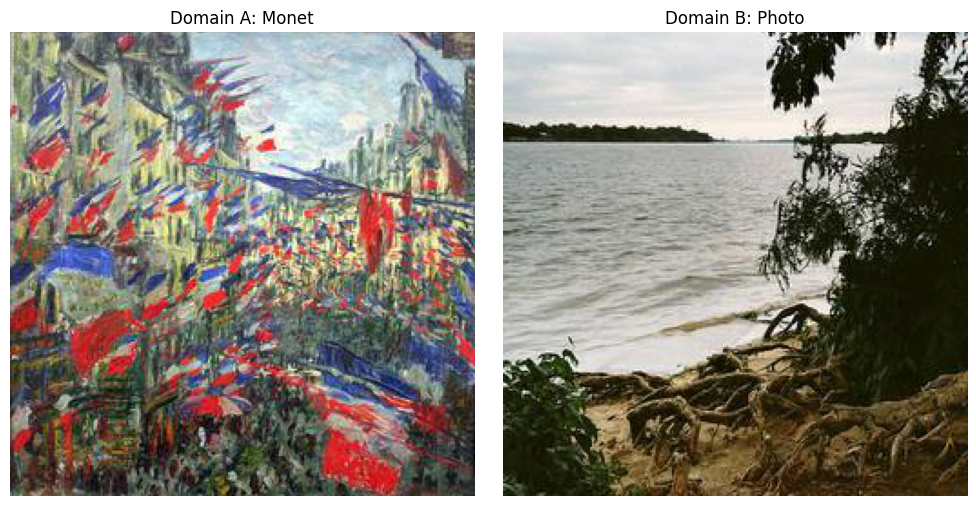

In [35]:
# Visual sanity check

def denormalize(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

batch = next(iter(train_loader))
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(denormalize(batch["domain_a"][0]).permute(1, 2, 0))
axes[0].set_title("Domain A: Monet")
axes[0].axis("off")
axes[1].imshow(denormalize(batch["domain_b"][0]).permute(1, 2, 0))
axes[1].set_title("Domain B: Photo")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. CycleGAN architecture

The four networks are implemented without prebuilt Transformer/GAN modules:

- `G_A2B`: Monet → Photo
- `G_B2A`: Photo → Monet
- `D_A`: Monet PatchGAN discriminator
- `D_B`: Photo PatchGAN discriminator

Nine residual blocks are used because the images are 256×256. This is a higher-capacity configuration than the earlier six-block version.

In [36]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, 1, 0),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, 1, 0),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


# My teammate runs the standard shape, nine residual blocks on 64 base
# filters. Mine spends the same parameter budget differently: six residual
# blocks on 80 base filters, so the bottleneck is wider and shallower. That
# gives 12,239,363 parameters per generator against her 11,378,179, close
# enough that any difference in the results is about where the capacity sits
# rather than how much there is. A wider bottleneck carries more feature
# channels at the smallest spatial size, which is where the texture and the
# colour palette of a style are represented.
class Generator(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, residual_blocks=6,
                 base_filters=80):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_channels, base_filters, 7),
            nn.InstanceNorm2d(base_filters),
            nn.ReLU(inplace=True)
        ]
        channels = base_filters
        for _ in range(2):
            next_channels = channels * 2
            layers += [
                nn.Conv2d(channels, next_channels, 3, 2, 1),
                nn.InstanceNorm2d(next_channels),
                nn.ReLU(inplace=True)
            ]
            channels = next_channels
        for _ in range(residual_blocks):
            layers.append(ResidualBlock(channels))
        for _ in range(2):
            next_channels = channels // 2
            layers += [
                nn.ConvTranspose2d(channels, next_channels, 3, 2, 1, output_padding=1),
                nn.InstanceNorm2d(next_channels),
                nn.ReLU(inplace=True)
            ]
            channels = next_channels
        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(channels, output_channels, 7),
            nn.Tanh()
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchDiscriminator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()

        def block(in_channels, out_channels, normalize=True):
            layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_channels))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(input_channels, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

G_A2B = Generator().to(DEVICE)
G_B2A = Generator().to(DEVICE)
D_A = PatchDiscriminator().to(DEVICE)
D_B = PatchDiscriminator().to(DEVICE)

total_parameters = sum(map(count_parameters, [G_A2B, G_B2A, D_A, D_B]))
print("G_A2B parameters:", f"{count_parameters(G_A2B):,}")
print("G_B2A parameters:", f"{count_parameters(G_B2A):,}")
print("D_A parameters:", f"{count_parameters(D_A):,}")
print("D_B parameters:", f"{count_parameters(D_B):,}")
print("Total trainable parameters:", f"{total_parameters:,}")

G_A2B parameters: 12,239,363
G_B2A parameters: 12,239,363
D_A parameters: 2,764,737
D_B parameters: 2,764,737
Total trainable parameters: 30,008,200


In [37]:
# Forward pass architecture check

with torch.no_grad():
    real_a = batch["domain_a"].to(DEVICE)
    real_b = batch["domain_b"].to(DEVICE)
    fake_b = G_A2B(real_a)
    fake_a = G_B2A(real_b)
    reconstructed_a = G_B2A(fake_b)
    reconstructed_b = G_A2B(fake_a)
    prediction_a = D_A(real_a)
    prediction_b = D_B(real_b)

print("Input shape:", tuple(real_a.shape))
print("Generated shape A2B:", tuple(fake_b.shape))
print("Generated shape B2A:", tuple(fake_a.shape))
print("Cycle shapes:", tuple(reconstructed_a.shape), tuple(reconstructed_b.shape))
print("PatchGAN output:", tuple(prediction_a.shape))
print("Outputs finite:", all(torch.isfinite(x).all().item() for x in [fake_a, fake_b, reconstructed_a, reconstructed_b]))

Input shape: (1, 3, 256, 256)
Generated shape A2B: (1, 3, 256, 256)
Generated shape B2A: (1, 3, 256, 256)
Cycle shapes: (1, 3, 256, 256) (1, 3, 256, 256)
PatchGAN output: (1, 1, 16, 16)
Outputs finite: True


## 4. Losses, optimization, and mixed precision

LSGAN/MSE adversarial loss is used with cycle-consistency and identity losses. bfloat16 is used on the RTX 5090 because the earlier FP16 experiment produced infinite gradient norms.

In [38]:
# Settable from the shell so a timing run needs no edit to this file:
#   DATA266_NUM_EPOCHS=1 jupyter nbconvert --execute ...
# Time one epoch first, then set the real value to fit the booked GPU slot.
NUM_EPOCHS = int(os.environ.get("DATA266_NUM_EPOCHS", 50))
CHECKPOINT_EVERY = int(os.environ.get("DATA266_CHECKPOINT_EVERY", 10))
LEARNING_RATE = 2e-4
BETAS = (0.5, 0.999)
LAMBDA_CYCLE = 10.0

# Identity loss asks the generator to leave an image alone when it is already
# in the target domain. It mostly holds the colour palette in place, which is
# why the CycleGAN paper adds it for the painting task. My teammate runs it at
# 5.0, half the cycle weight, which is the usual setting. I run it at 2.5.
# The reason is that the Monet direction is scored on how much the output
# looks repainted, and a strong identity term works against exactly that by
# penalising the colour shift a Monet needs. Lowering it frees the generator
# to repaint more. The risk is colour drift on photographs that were already
# close to the Monet palette, so this is one of the things to look at in the
# failure analysis.
LAMBDA_IDENTITY = 2.5
GRADIENT_CLIP = 1.0

USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if USE_AMP else torch.float32
# No gradient scaler. Scaling exists to stop float16 underflowing, and
# bfloat16 has the same exponent range as float32 so it does not need it.
# This was a disabled GradScaler that nothing ever used, and the newer
# torch.amp.GradScaler spelling does not exist before torch 2.4, so it
# broke the notebook on a lab container running 2.1.
scaler = None

adversarial_loss = nn.MSELoss()
cycle_loss_function = nn.L1Loss()
identity_loss_function = nn.L1Loss()

optimizer_generators = torch.optim.Adam(
    list(G_A2B.parameters()) + list(G_B2A.parameters()),
    lr=LEARNING_RATE,
    betas=BETAS
)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=LEARNING_RATE, betas=BETAS)
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=LEARNING_RATE, betas=BETAS)

print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("AMP dtype:", AMP_DTYPE)

Epochs: 50
Learning rate: 0.0002
AMP dtype: torch.bfloat16


In [39]:
# Artifacts are anchored to this member's folder in the team repo, so results
# land in the structure the brief grades (checkpoints/, outputs/pred_A2B,
# outputs/pred_B2A) no matter which directory the notebook was started from.
# If the repo is not present, for example on a bare lab node, everything falls
# back to a local folder that can be copied into the repo afterwards.
#
# A laptop smoke test writes checkpoints and logs too, and those must never be
# mistaken for the real run's artifacts or silently resumed on the lab
# machine, so a non CUDA run is redirected into a smoke/ subfolder.
MEMBER_NAME = "anees_saheba"


def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / ".git").exists() and (candidate / "task3_gan").is_dir():
            return candidate
    return None


REPO_ROOT = find_repo_root()
SMOKE_RUN = DEVICE.type != "cuda"

if REPO_ROOT is not None:
    MEMBER_ROOT = REPO_ROOT / "task3_gan" / MEMBER_NAME
    RAW_LOG_DIR = REPO_ROOT / "reproducibility" / "raw_logs"
else:
    MEMBER_ROOT = Path.cwd() / "task3_gan_output"
    RAW_LOG_DIR = MEMBER_ROOT / "raw_logs"

if SMOKE_RUN:
    MEMBER_ROOT = MEMBER_ROOT / "smoke"
    RAW_LOG_DIR = MEMBER_ROOT / "raw_logs"

OUTPUT_ROOT = MEMBER_ROOT
CHECKPOINT_DIR = MEMBER_ROOT / "checkpoints"
OUTPUT_DIR = MEMBER_ROOT / "outputs"
TRANSLATION_DIR = OUTPUT_DIR            # pred_A2B / pred_B2A land directly here
FIGURE_DIR = OUTPUT_DIR / "figures"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [CHECKPOINT_DIR, OUTPUT_DIR, FIGURE_DIR, METRIC_DIR, RAW_LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Repo root  :", REPO_ROOT if REPO_ROOT else "(not found, using local fallback)")
print("Member root:", MEMBER_ROOT)
print("Raw logs   :", RAW_LOG_DIR)
print("Smoke run  :", SMOKE_RUN)

# One raw log per session. A resumed run gets its own file, so the set of logs
# together is the full evidence trail for the run and no file is ever rewritten.
RUN_ID = time.strftime("%Y%m%d_%H%M%S")
RAW_LOG_PATH = RAW_LOG_DIR / f"task3_cyclegan_{RUN_ID}.log"


def log_line(message):
    """Append one timestamped line to the raw log and echo it to the notebook.

    Opened in append mode and flushed on every write, so the log survives a
    killed kernel or an interrupted lab session. This file is the evidence
    trail and is never edited after the run.
    """
    stamped = f"{time.strftime('%Y-%m-%d %H:%M:%S')} {message}"
    print(stamped)
    with RAW_LOG_PATH.open("a", encoding="utf-8") as handle:
        handle.write(stamped + "\n")
        handle.flush()


log_line(f"run_id={RUN_ID} device={DEVICE} gpu={GPU_NAME} seed={SEED}")
log_line(f"epochs={NUM_EPOCHS} lr={LEARNING_RATE} lambda_cycle={LAMBDA_CYCLE} "
         f"lambda_identity={LAMBDA_IDENTITY} image_size={IMAGE_SIZE} batch_size={BATCH_SIZE}")
print("Raw log:", RAW_LOG_PATH)

def linear_decay_rule(epoch):
    decay_start = NUM_EPOCHS // 2
    if epoch < decay_start:
        return 1.0
    return max(0.0, 1.0 - (epoch - decay_start) / (NUM_EPOCHS - decay_start))

scheduler_generators = torch.optim.lr_scheduler.LambdaLR(optimizer_generators, linear_decay_rule)
scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, linear_decay_rule)
scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, linear_decay_rule)

print("Training epochs:", NUM_EPOCHS)
print("Decay begins after epoch:", NUM_EPOCHS // 2)

Repo root  : (not found, using local fallback)
Member root: /app/task3_gan_output
Raw logs   : /app/task3_gan_output/raw_logs
Smoke run  : False
2026-10-05 20:15:41 run_id=20261005_201541 device=cuda gpu=NVIDIA GeForce RTX 4090 seed=5330
2026-10-05 20:15:41 epochs=50 lr=0.0002 lambda_cycle=10.0 lambda_identity=2.5 image_size=256 batch_size=1
Raw log: /app/task3_gan_output/raw_logs/task3_cyclegan_20261005_201541.log
Training epochs: 50
Decay begins after epoch: 25


In [40]:
def set_requires_grad(models, value):
    for model in models:
        for parameter in model.parameters():
            parameter.requires_grad_(value)


def finite_number(value):
    return bool(np.isfinite(float(value)))


def cycle_gan_train_step(real_a, real_b):
    real_a = real_a.to(DEVICE, non_blocking=True)
    real_b = real_b.to(DEVICE, non_blocking=True)

    set_requires_grad([D_A, D_B], False)
    optimizer_generators.zero_grad(set_to_none=True)

    with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
        identity_a = G_B2A(real_a)
        identity_b = G_A2B(real_b)
        fake_b = G_A2B(real_a)
        fake_a = G_B2A(real_b)
        reconstructed_a = G_B2A(fake_b)
        reconstructed_b = G_A2B(fake_a)

        # Keep each discriminator prediction instead of recomputing it for the
        # target tensor: D_B(fake_b) was previously evaluated twice per step.
        pred_fake_b = D_B(fake_b)
        pred_fake_a = D_A(fake_a)
        adv_a2b = adversarial_loss(pred_fake_b, torch.ones_like(pred_fake_b))
        adv_b2a = adversarial_loss(pred_fake_a, torch.ones_like(pred_fake_a))
        cycle_a = cycle_loss_function(reconstructed_a, real_a)
        cycle_b = cycle_loss_function(reconstructed_b, real_b)
        identity_a_loss = identity_loss_function(identity_a, real_a)
        identity_b_loss = identity_loss_function(identity_b, real_b)

        generator_loss = (
            adv_a2b + adv_b2a
            + LAMBDA_CYCLE * (cycle_a + cycle_b)
            + LAMBDA_IDENTITY * (identity_a_loss + identity_b_loss)
        )

    generator_loss.backward()
    generator_grad_norm = torch.nn.utils.clip_grad_norm_(
        list(G_A2B.parameters()) + list(G_B2A.parameters()), GRADIENT_CLIP
    ).item()
    optimizer_generators.step()

    set_requires_grad([D_A, D_B], True)
    optimizer_D_A.zero_grad(set_to_none=True)
    optimizer_D_B.zero_grad(set_to_none=True)

    with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
        fake_a_detached = fake_a.detach()
        fake_b_detached = fake_b.detach()
        real_a_pred = D_A(real_a)
        fake_a_pred = D_A(fake_a_detached)
        real_b_pred = D_B(real_b)
        fake_b_pred = D_B(fake_b_detached)
        discriminator_a_loss = 0.5 * (
            adversarial_loss(real_a_pred, torch.ones_like(real_a_pred))
            + adversarial_loss(fake_a_pred, torch.zeros_like(fake_a_pred))
        )
        discriminator_b_loss = 0.5 * (
            adversarial_loss(real_b_pred, torch.ones_like(real_b_pred))
            + adversarial_loss(fake_b_pred, torch.zeros_like(fake_b_pred))
        )
        discriminator_loss = discriminator_a_loss + discriminator_b_loss

    discriminator_loss.backward()
    discriminator_grad_norm = torch.nn.utils.clip_grad_norm_(
        list(D_A.parameters()) + list(D_B.parameters()), GRADIENT_CLIP
    ).item()
    optimizer_D_A.step()
    optimizer_D_B.step()

    values = {
        "generator_loss": generator_loss.detach().float().item(),
        "discriminator_loss": discriminator_loss.detach().float().item(),
        "cycle_a_loss": cycle_a.detach().float().item(),
        "cycle_b_loss": cycle_b.detach().float().item(),
        "identity_a_loss": identity_a_loss.detach().float().item(),
        "identity_b_loss": identity_b_loss.detach().float().item(),
        "generator_gradient_norm": float(generator_grad_norm),
        "discriminator_gradient_norm": float(discriminator_grad_norm)
    }
    values["nan_or_inf_detected"] = int(
        not all(finite_number(v) for v in values.values())
    )
    return values

In [41]:
# Numerical smoke test. Do not start full training unless this reports 0.
#
# cycle_gan_train_step performs real optimizer steps, so running it here would
# leave the weights one update ahead with Adam moment estimates already
# populated, and training would not begin from the clean seeded
# initialisation. Model, optimizer and RNG state are snapshotted and restored
# around the test so it observes the step without keeping it.
import copy

_SMOKE_MODELS = {"G_A2B": G_A2B, "G_B2A": G_B2A, "D_A": D_A, "D_B": D_B}
_SMOKE_OPTIMIZERS = {
    "generators": optimizer_generators,
    "D_A": optimizer_D_A,
    "D_B": optimizer_D_B,
}

_smoke_snapshot = {
    "models": {k: copy.deepcopy(m.state_dict()) for k, m in _SMOKE_MODELS.items()},
    "optimizers": {k: copy.deepcopy(o.state_dict()) for k, o in _SMOKE_OPTIMIZERS.items()},
    "torch_rng": torch.get_rng_state(),
    "cuda_rng": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    "numpy_rng": np.random.get_state(),
    "python_rng": random.getstate(),
}

G_A2B.train(); G_B2A.train(); D_A.train(); D_B.train()
smoke_batch = next(iter(train_loader))
smoke_metrics = cycle_gan_train_step(smoke_batch["domain_a"], smoke_batch["domain_b"])
for name, value in smoke_metrics.items():
    print(f"{name}: {value}")

for name, module in _SMOKE_MODELS.items():
    module.load_state_dict(_smoke_snapshot["models"][name])
for name, optimizer in _SMOKE_OPTIMIZERS.items():
    optimizer.load_state_dict(_smoke_snapshot["optimizers"][name])
torch.set_rng_state(_smoke_snapshot["torch_rng"])
if _smoke_snapshot["cuda_rng"] is not None:
    torch.cuda.set_rng_state_all(_smoke_snapshot["cuda_rng"])
np.random.set_state(_smoke_snapshot["numpy_rng"])
random.setstate(_smoke_snapshot["python_rng"])

print()
print("NaN/Inf detected:", smoke_metrics["nan_or_inf_detected"])
print("State restored: training starts from the seeded initialisation, not one step in.")

generator_loss: 15.323972702026367
discriminator_loss: 1.181868553161621
cycle_a_loss: 0.6102957725524902
cycle_b_loss: 0.4553734064102173
identity_a_loss: 0.5999177098274231
identity_b_loss: 0.4542979598045349
generator_gradient_norm: 104.68905639648438
discriminator_gradient_norm: 32.8322639465332
nan_or_inf_detected: 0

NaN/Inf detected: 0
State restored: training starts from the seeded initialisation, not one step in.


## 5. Training, validation, checkpointing, and stability logging

The loop supports a fresh 50-epoch run and stores complete state dictionaries. It records the required timing, memory, gradient, and NaN/Inf evidence.

In [42]:
@torch.no_grad()
def evaluate_cyclegan(loader):
    G_A2B.eval(); G_B2A.eval(); D_A.eval(); D_B.eval()
    totals = defaultdict(float)
    count = 0
    for batch in loader:
        real_a = batch["domain_a"].to(DEVICE, non_blocking=True)
        real_b = batch["domain_b"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            identity_a = G_B2A(real_a); identity_b = G_A2B(real_b)
            fake_b = G_A2B(real_a); fake_a = G_B2A(real_b)
            rec_a = G_B2A(fake_b); rec_b = G_A2B(fake_a)
            pred_fake_b = D_B(fake_b); pred_fake_a = D_A(fake_a)
            pred_real_a = D_A(real_a); pred_real_b = D_B(real_b)
            adv_a2b = adversarial_loss(pred_fake_b, torch.ones_like(pred_fake_b))
            adv_b2a = adversarial_loss(pred_fake_a, torch.ones_like(pred_fake_a))
            cycle_a = cycle_loss_function(rec_a, real_a)
            cycle_b = cycle_loss_function(rec_b, real_b)
            id_a = identity_loss_function(identity_a, real_a)
            id_b = identity_loss_function(identity_b, real_b)
            g_loss = adv_a2b + adv_b2a + LAMBDA_CYCLE*(cycle_a+cycle_b) + LAMBDA_IDENTITY*(id_a+id_b)
            d_a = 0.5*(adversarial_loss(pred_real_a, torch.ones_like(pred_real_a)) + adversarial_loss(pred_fake_a, torch.zeros_like(pred_fake_a)))
            d_b = 0.5*(adversarial_loss(pred_real_b, torch.ones_like(pred_real_b)) + adversarial_loss(pred_fake_b, torch.zeros_like(pred_fake_b)))
        for name, value in {"generator_loss":g_loss, "discriminator_loss":d_a+d_b, "cycle_a_loss":cycle_a, "cycle_b_loss":cycle_b, "identity_a_loss":id_a, "identity_b_loss":id_b}.items():
            totals[name] += float(value.float().item())
        count += 1
    return {name: value / count for name, value in totals.items()}


CONFIG_SNAPSHOT = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "residual_blocks": 9,
    "lambda_cycle": LAMBDA_CYCLE,
    "lambda_identity": LAMBDA_IDENTITY
}


def save_resume_checkpoint(epoch, history, elapsed_seconds):
    """Full training state, written to a single rolling file.

    Measured size is 340 MB: four models plus three Adam optimizer states.
    Keeping one per milestone would be 4 GB across a 50-epoch run and every
    file would exceed GitHub's 100 MB limit, so this one is overwritten each
    epoch and exists only to resume an interrupted run.

    Written to a temporary file and renamed, so a session killed mid-write
    leaves the previous checkpoint intact rather than a truncated one.
    """
    path = CHECKPOINT_DIR / "latest.pt"
    temporary = CHECKPOINT_DIR / "latest.pt.tmp"
    torch.save({
        "epoch": epoch,
        "seed": SEED,
        "gpu_name": GPU_NAME,
        "config": CONFIG_SNAPSHOT,
        "G_A2B": G_A2B.state_dict(), "G_B2A": G_B2A.state_dict(),
        "D_A": D_A.state_dict(), "D_B": D_B.state_dict(),
        "optimizer_generators": optimizer_generators.state_dict(),
        "optimizer_D_A": optimizer_D_A.state_dict(),
        "optimizer_D_B": optimizer_D_B.state_dict(),
        "scheduler_generators": scheduler_generators.state_dict(),
        "scheduler_D_A": scheduler_D_A.state_dict(),
        "scheduler_D_B": scheduler_D_B.state_dict(),
        "history": history,
        "elapsed_seconds": elapsed_seconds
    }, temporary)
    temporary.replace(path)
    return path


def save_generator_milestone(epoch):
    """Generators only: 91 MB, and all that inference or the report needs.

    Discriminators and optimizer state are training scaffolding and are not
    required to reproduce a translation from a given epoch.
    """
    path = CHECKPOINT_DIR / f"generators_epoch_{epoch:03d}.pt"
    torch.save({
        "epoch": epoch,
        "seed": SEED,
        "config": CONFIG_SNAPSHOT,
        "G_A2B": G_A2B.state_dict(),
        "G_B2A": G_B2A.state_dict()
    }, path)
    return path


# Resume support. One epoch is len(train_loader) steps at batch size 1, so a
# full run is long enough that a GPU lab slot can end before it finishes, and
# lab machines are wiped afterwards. Setting RESUME keeps an interrupted run
# recoverable from latest.pt instead of restarting from epoch 1.
RESUME = True

history = {"train": [], "validation": [], "epoch_time_seconds": [], "images_per_second": [], "peak_memory_gb": [], "nan_or_inf_count": []}
start_epoch = 1
prior_elapsed_seconds = 0.0

latest_checkpoint = CHECKPOINT_DIR / "latest.pt"
if RESUME and latest_checkpoint.exists():
    # weights_only=False because the checkpoint carries the history dict,
    # not only tensors.
    checkpoint = torch.load(latest_checkpoint, map_location=DEVICE, weights_only=False)

    # Resuming the wrong checkpoint is silent and ruins the run, so verify it
    # belongs to this configuration before loading any weights from it.
    if checkpoint.get("seed") != SEED:
        raise RuntimeError(
            f"{latest_checkpoint} was written with seed {checkpoint.get('seed')}, "
            f"but this run uses seed {SEED}. Move it aside or set RESUME = False."
        )
    if checkpoint.get("config") != CONFIG_SNAPSHOT:
        differences = {
            key: (checkpoint.get("config", {}).get(key), value)
            for key, value in CONFIG_SNAPSHOT.items()
            if checkpoint.get("config", {}).get(key) != value
        }
        raise RuntimeError(
            f"{latest_checkpoint} was written with a different configuration "
            f"(checkpoint, current): {differences}. Move it aside or set RESUME = False."
        )
    if checkpoint.get("gpu_name") != GPU_NAME:
        log_line(f"WARNING resuming on {GPU_NAME} from a checkpoint written on "
                 f"{checkpoint.get('gpu_name')}")

    for name, obj in [
        ("G_A2B", G_A2B), ("G_B2A", G_B2A), ("D_A", D_A), ("D_B", D_B),
        ("optimizer_generators", optimizer_generators),
        ("optimizer_D_A", optimizer_D_A), ("optimizer_D_B", optimizer_D_B),
        ("scheduler_generators", scheduler_generators),
        ("scheduler_D_A", scheduler_D_A), ("scheduler_D_B", scheduler_D_B)
    ]:
        obj.load_state_dict(checkpoint[name])
    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"] + 1
    prior_elapsed_seconds = checkpoint.get("elapsed_seconds", 0.0)
    log_line(f"RESUME from epoch {checkpoint['epoch']}, continuing at epoch {start_epoch}, "
             f"prior_hours={prior_elapsed_seconds / 3600:.3f}")
else:
    log_line("FRESH RUN from epoch 1")

training_start = time.perf_counter()

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    epoch_start = time.perf_counter()
    G_A2B.train(); G_B2A.train(); D_A.train(); D_B.train()
    totals = defaultdict(float)
    nan_count = 0
    reset_peak_memory()

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")
    for batch_index, batch in enumerate(progress, start=1):
        metrics = cycle_gan_train_step(batch["domain_a"], batch["domain_b"])
        nan_count += metrics.pop("nan_or_inf_detected")
        for name, value in metrics.items():
            totals[name] += value
        if batch_index % 500 == 0:
            progress.set_postfix(G=f"{metrics['generator_loss']:.3f}", D=f"{metrics['discriminator_loss']:.3f}")
            # Step level losses and gradient norms go to the raw log so
            # instability can be located in time, not just seen as an epoch mean.
            log_line(
                f"epoch {epoch} step {batch_index}/{len(train_loader)} "
                f"G={metrics['generator_loss']:.4f} D={metrics['discriminator_loss']:.4f} "
                f"cycle_a={metrics['cycle_a_loss']:.4f} cycle_b={metrics['cycle_b_loss']:.4f} "
                f"id_a={metrics['identity_a_loss']:.4f} id_b={metrics['identity_b_loss']:.4f} "
                f"gnorm_G={metrics['generator_gradient_norm']:.4f} "
                f"gnorm_D={metrics['discriminator_gradient_norm']:.4f}"
            )

    train_metrics = {name: value / len(train_loader) for name, value in totals.items()}
    validation_metrics = evaluate_cyclegan(validation_loader)
    scheduler_generators.step(); scheduler_D_A.step(); scheduler_D_B.step()

    epoch_time = time.perf_counter() - epoch_start
    images_per_second = (len(train_loader) * 2) / epoch_time
    peak_memory = peak_memory_gb()
    history["train"].append(train_metrics); history["validation"].append(validation_metrics)
    history["epoch_time_seconds"].append(epoch_time); history["images_per_second"].append(images_per_second)
    history["peak_memory_gb"].append(peak_memory); history["nan_or_inf_count"].append(nan_count)

    log_line(
        f"EPOCH {epoch}/{NUM_EPOCHS} "
        f"train_G={train_metrics['generator_loss']:.4f} train_D={train_metrics['discriminator_loss']:.4f} "
        f"val_G={validation_metrics['generator_loss']:.4f} val_D={validation_metrics['discriminator_loss']:.4f} "
        f"cycle_a={train_metrics['cycle_a_loss']:.4f} cycle_b={train_metrics['cycle_b_loss']:.4f} "
        f"gnorm_G={train_metrics['generator_gradient_norm']:.4f} "
        f"gnorm_D={train_metrics['discriminator_gradient_norm']:.4f} "
        f"seconds={epoch_time:.2f} images_per_sec={images_per_second:.2f} "
        f"peak_gb={peak_memory:.3f} nan_inf={nan_count} lr={optimizer_generators.param_groups[0]['lr']:.6f}"
    )

    # Rolling full state every epoch so an interrupted slot loses at most one.
    save_resume_checkpoint(epoch, history, prior_elapsed_seconds + time.perf_counter() - training_start)
    if epoch == 1 or epoch % CHECKPOINT_EVERY == 0 or epoch == NUM_EPOCHS:
        log_line(f"MILESTONE saved {save_generator_milestone(epoch)}")

# Cumulative across resumes, so the reported figure is the real total rather
# than only the final session.
total_training_time = prior_elapsed_seconds + (time.perf_counter() - training_start)
log_line(f"TRAINING COMPLETE total_hours={total_training_time / 3600:.3f}")

2026-10-05 20:15:42 FRESH RUN from epoch 1


Epoch 1/50:   8%|▊         | 500/6335 [00:51<09:38, 10.09it/s, D=0.249, G=7.445]

2026-10-05 20:16:33 epoch 1 step 500/6335 G=7.4449 D=0.2490 cycle_a=0.2370 cycle_b=0.2818 id_a=0.2277 id_b=0.2885 gnorm_G=45.7813 gnorm_D=7.9644


Epoch 1/50:  16%|█▌        | 1001/6335 [01:38<08:27, 10.51it/s, D=0.741, G=8.734]

2026-10-05 20:17:20 epoch 1 step 1000/6335 G=8.7340 D=0.7408 cycle_a=0.4087 cycle_b=0.2555 id_a=0.4200 id_b=0.1957 gnorm_G=54.5865 gnorm_D=17.7252


...

2026-10-06 05:10:34 epoch 50 step 5500/6335 G=3.4828 D=0.0481 cycle_a=0.0866 cycle_b=0.0694 id_a=0.0572 id_b=0.0451 gnorm_G=20.6193 gnorm_D=5.9710


Epoch 50/50:  95%|█████████▍| 6001/6335 [10:00<00:37,  8.87it/s, D=0.144, G=3.704]

2026-10-06 05:11:25 epoch 50 step 6000/6335 G=3.7039 D=0.1441 cycle_a=0.0553 cycle_b=0.0873 id_a=0.0556 id_b=0.0647 gnorm_G=14.9710 gnorm_D=10.9925


Epoch 50/50: 100%|██████████| 6335/6335 [10:34<00:00,  9.98it/s, D=0.144, G=3.704]


2026-10-06 05:12:17 EPOCH 50/50 train_G=3.3199 train_D=0.1800 val_G=6.7979 val_D=1.1442 cycle_a=0.0797 cycle_b=0.0752 gnorm_G=17.0465 gnorm_D=9.1994 seconds=653.31 images_per_sec=19.39 peak_gb=1.562 nan_inf=0 lr=0.000000
2026-10-06 05:12:19 MILESTONE saved /app/task3_gan_output/checkpoints/generators_epoch_050.pt
2026-10-06 05:12:19 TRAINING COMPLETE total_hours=8.944


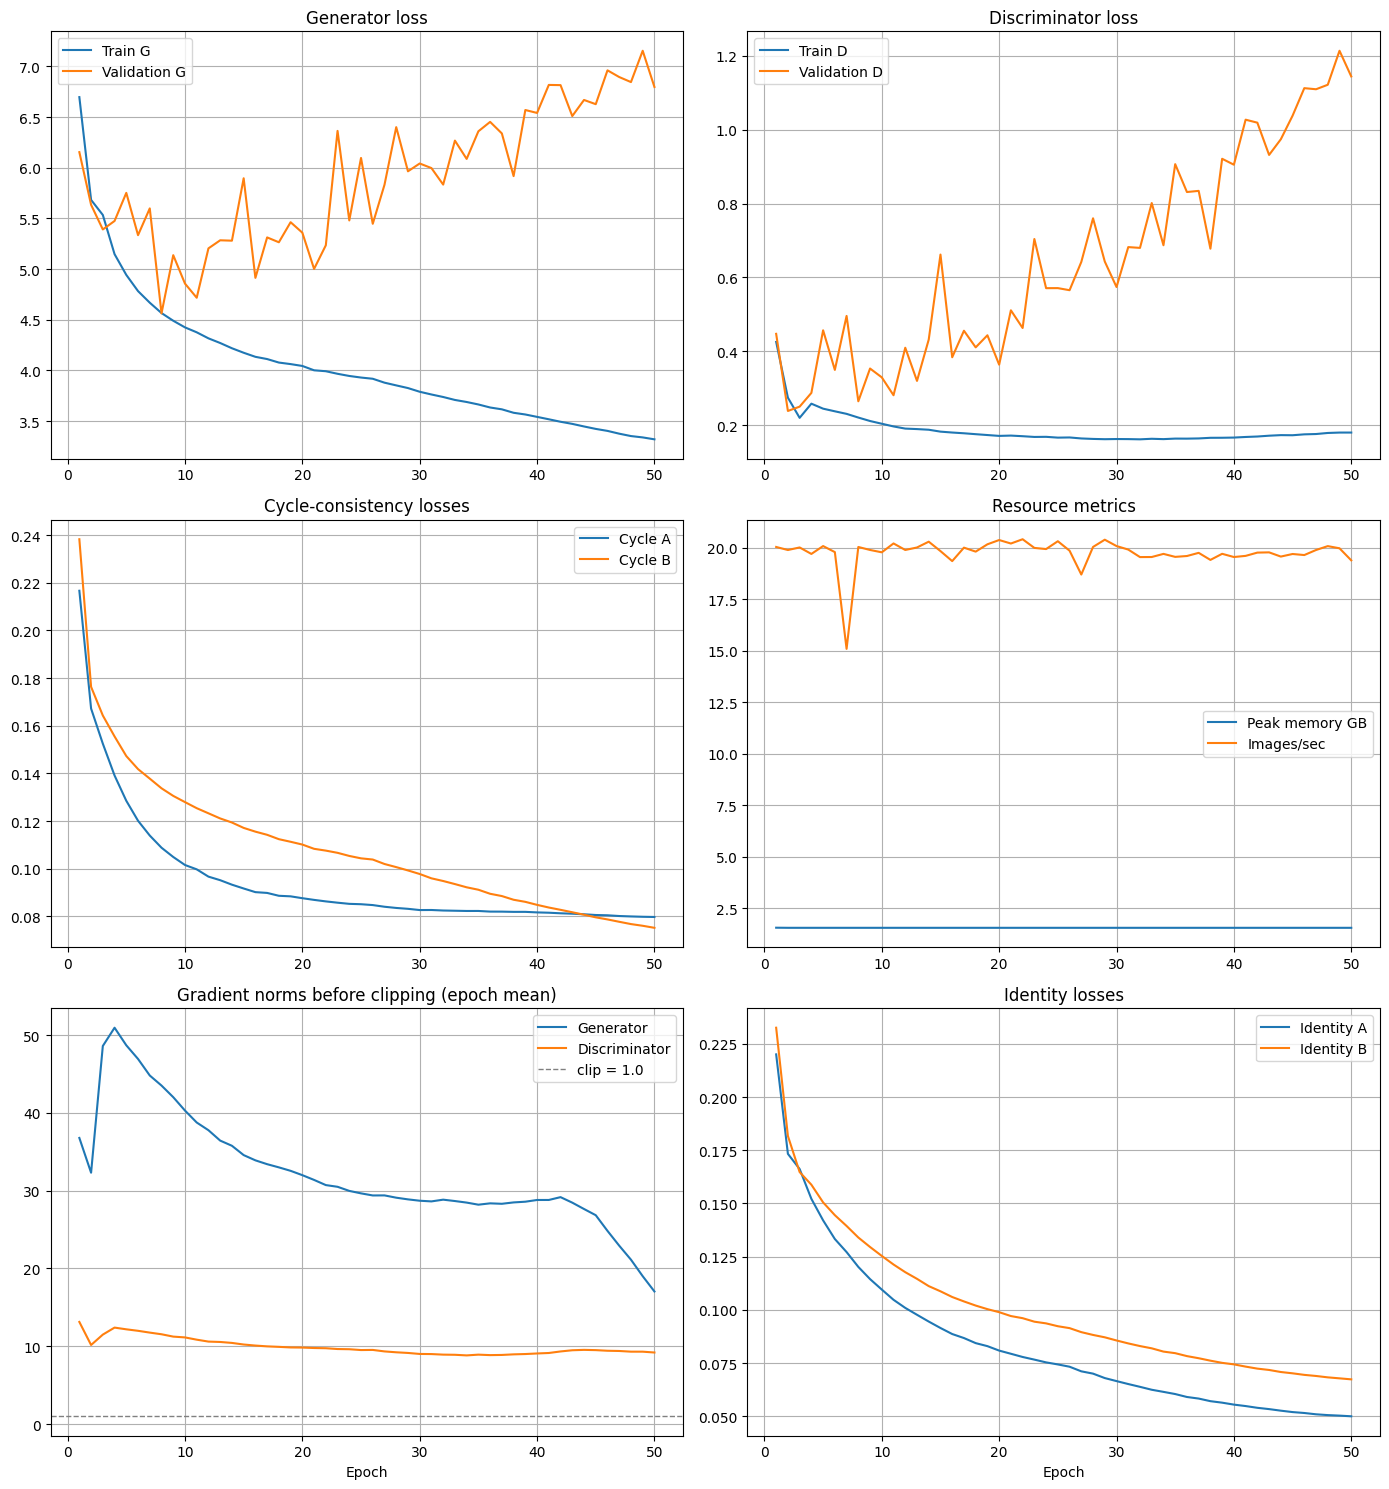

In [43]:
# Save machine readable training history and plot required curves

with open(METRIC_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)

epochs = np.arange(1, len(history["train"]) + 1)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes[0, 0].plot(epochs, [x["generator_loss"] for x in history["train"]], label="Train G")
axes[0, 0].plot(epochs, [x["generator_loss"] for x in history["validation"]], label="Validation G")
axes[0, 0].set_title("Generator loss"); axes[0, 0].legend(); axes[0, 0].grid()
axes[0, 1].plot(epochs, [x["discriminator_loss"] for x in history["train"]], label="Train D")
axes[0, 1].plot(epochs, [x["discriminator_loss"] for x in history["validation"]], label="Validation D")
axes[0, 1].set_title("Discriminator loss"); axes[0, 1].legend(); axes[0, 1].grid()
axes[1, 0].plot(epochs, [x["cycle_a_loss"] for x in history["train"]], label="Cycle A")
axes[1, 0].plot(epochs, [x["cycle_b_loss"] for x in history["train"]], label="Cycle B")
axes[1, 0].set_title("Cycle-consistency losses"); axes[1, 0].legend(); axes[1, 0].grid()
axes[1, 1].plot(epochs, history["peak_memory_gb"], label="Peak memory GB")
axes[1, 1].plot(epochs, history["images_per_second"], label="Images/sec")
axes[1, 1].set_title("Resource metrics"); axes[1, 1].legend(); axes[1, 1].grid()

# Gradient norms are a required metric and the main epoch level evidence for
# training stability; the loss curves alone do not show it. These are the
# pre clip norms returned by clip_grad_norm_, averaged over each epoch, so a
# value persistently at or above GRADIENT_CLIP means clipping is active.
axes[2, 0].plot(epochs, [x["generator_gradient_norm"] for x in history["train"]], label="Generator")
axes[2, 0].plot(epochs, [x["discriminator_gradient_norm"] for x in history["train"]], label="Discriminator")
axes[2, 0].axhline(GRADIENT_CLIP, linestyle="--", linewidth=1, color="grey", label=f"clip = {GRADIENT_CLIP}")
axes[2, 0].set_title("Gradient norms before clipping (epoch mean)")
axes[2, 0].set_xlabel("Epoch"); axes[2, 0].legend(); axes[2, 0].grid()

axes[2, 1].plot(epochs, [x["identity_a_loss"] for x in history["train"]], label="Identity A")
axes[2, 1].plot(epochs, [x["identity_b_loss"] for x in history["train"]], label="Identity B")
axes[2, 1].set_title("Identity losses")
axes[2, 1].set_xlabel("Epoch"); axes[2, 1].legend(); axes[2, 1].grid()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=160)
plt.show()

## 6. Generate translations and verify cycle consistency

In [44]:
@torch.no_grad()
def generate_translations(loader, split_name, max_items=30):
    G_A2B.eval(); G_B2A.eval()
    output_a2b = TRANSLATION_DIR / f"{split_name}_A2B"
    output_b2a = TRANSLATION_DIR / f"{split_name}_B2A"
    output_cycle_a = TRANSLATION_DIR / f"{split_name}_cycle_A"
    output_cycle_b = TRANSLATION_DIR / f"{split_name}_cycle_B"
    for folder in [output_a2b, output_b2a, output_cycle_a, output_cycle_b]:
        folder.mkdir(parents=True, exist_ok=True)

    rows = []
    for index, batch in enumerate(loader):
        if max_items is not None and index >= max_items:
            break
        real_a = batch["domain_a"].to(DEVICE)
        real_b = batch["domain_b"].to(DEVICE)
        fake_b = G_A2B(real_a)
        fake_a = G_B2A(real_b)
        rec_a = G_B2A(fake_b)
        rec_b = G_A2B(fake_a)
        save_image(denormalize(fake_b[0]), output_a2b / f"{index:04d}.png")
        save_image(denormalize(fake_a[0]), output_b2a / f"{index:04d}.png")
        save_image(denormalize(rec_a[0]), output_cycle_a / f"{index:04d}.png")
        save_image(denormalize(rec_b[0]), output_cycle_b / f"{index:04d}.png")
        rows.append({
            "index": index,
            "input_a": batch["domain_a_path"][0],
            "input_b": batch["domain_b_path"][0],
            "output_a2b": str(output_a2b / f"{index:04d}.png"),
            "output_b2a": str(output_b2a / f"{index:04d}.png"),
            "cycle_a": str(output_cycle_a / f"{index:04d}.png"),
            "cycle_b": str(output_cycle_b / f"{index:04d}.png")
        })
    manifest = pd.DataFrame(rows)
    manifest.to_csv(METRIC_DIR / f"{split_name}_translation_manifest.csv", index=False)
    return manifest

validation_manifest = generate_translations(validation_loader, "validation", max_items=30)
print("Generated validation translations:", len(validation_manifest))

# Full held out evaluation set, each image translated exactly once.
#
# The paired validation_loader has length max(30, 703) = 703 and cycles the
# shorter domain with index % len(...). Driving the evaluation from it would
# feed the same 30 Monet validation images roughly 23 times each, and those
# duplicates distort FID, KID, density and coverage. Each domain is therefore
# translated on its own below.

class SingleDomainDataset(Dataset):
    """One domain only, so every image is translated exactly once."""

    def __init__(self, paths, transform):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        with Image.open(path) as image:
            image = image.convert("RGB")
        return self.transform(image), str(path)


@torch.no_grad()
def translate_paths(generator, paths, output_dir, extension="png", batch_size=16):
    """Translate each path once, naming each output after its source image.

    Batching is safe here because the generators use InstanceNorm, which
    normalizes each image independently of the others in the batch.
    """
    generator.eval()
    output_dir.mkdir(parents=True, exist_ok=True)
    loader = DataLoader(
        SingleDomainDataset(paths, validation_transform),
        batch_size=batch_size, shuffle=False, num_workers=0
    )
    written = []
    for images, sources in tqdm(loader, desc=f"Translating to {output_dir.name}"):
        generated = generator(images.to(DEVICE))
        for image, source in zip(generated, sources):
            destination = output_dir / f"{Path(source).stem}.{extension}"
            save_image(denormalize(image), destination)
            written.append(destination)
    return written


PRED_A2B_DIR = TRANSLATION_DIR / "pred_A2B"
PRED_B2A_DIR = TRANSLATION_DIR / "pred_B2A"

fake_photo_paths = translate_paths(G_A2B, monet_val_images, PRED_A2B_DIR)
fake_monet_paths = translate_paths(G_B2A, photo_val_images, PRED_B2A_DIR)

print("A2B (Monet to photo):", len(fake_photo_paths), "from", len(monet_val_images), "sources")
print("B2A (photo to Monet):", len(fake_monet_paths), "from", len(photo_val_images), "sources")
assert len(fake_photo_paths) == len(monet_val_images), "A2B count does not match its source set"
assert len(fake_monet_paths) == len(photo_val_images), "B2A count does not match its source set"

Generated validation translations: 30


Translating to pred_B2A: 100%|██████████| 44/44 [00:22<00:00,  1.94it/s]

A2B (Monet to photo): 30 from 30 sources
B2A (photo to Monet): 703 from 703 sources


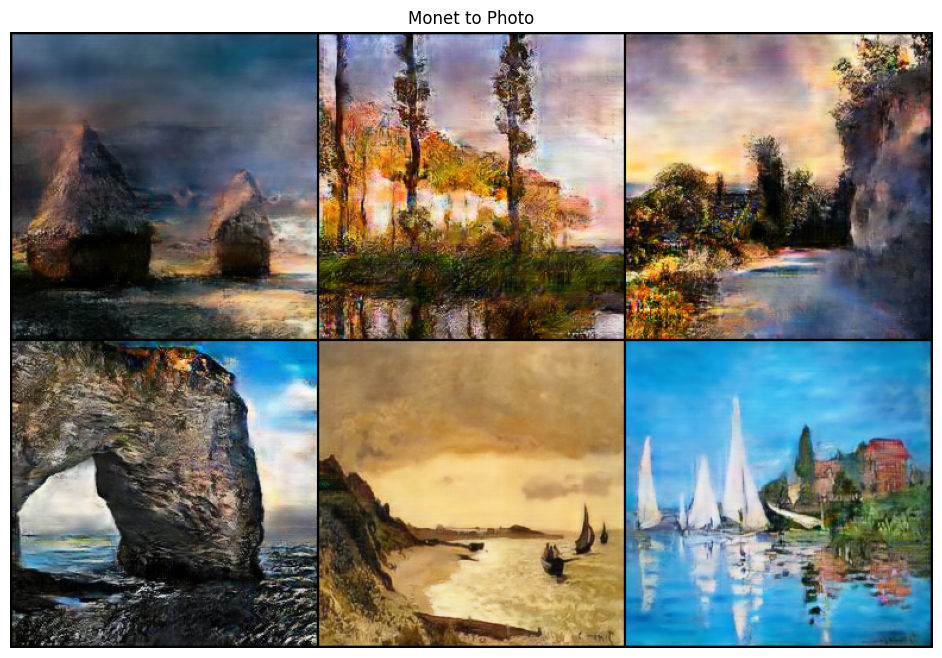

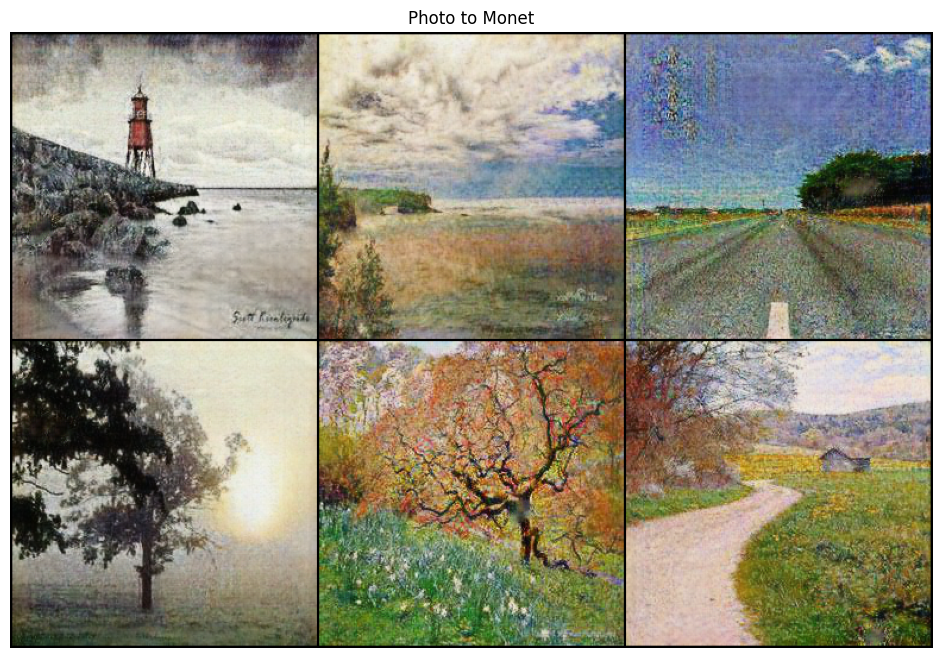

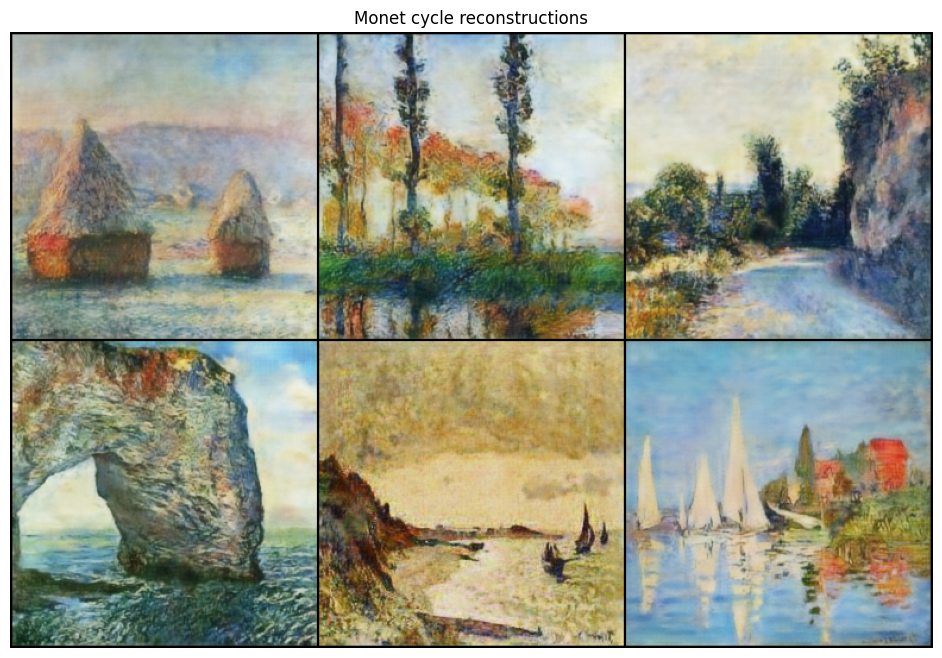

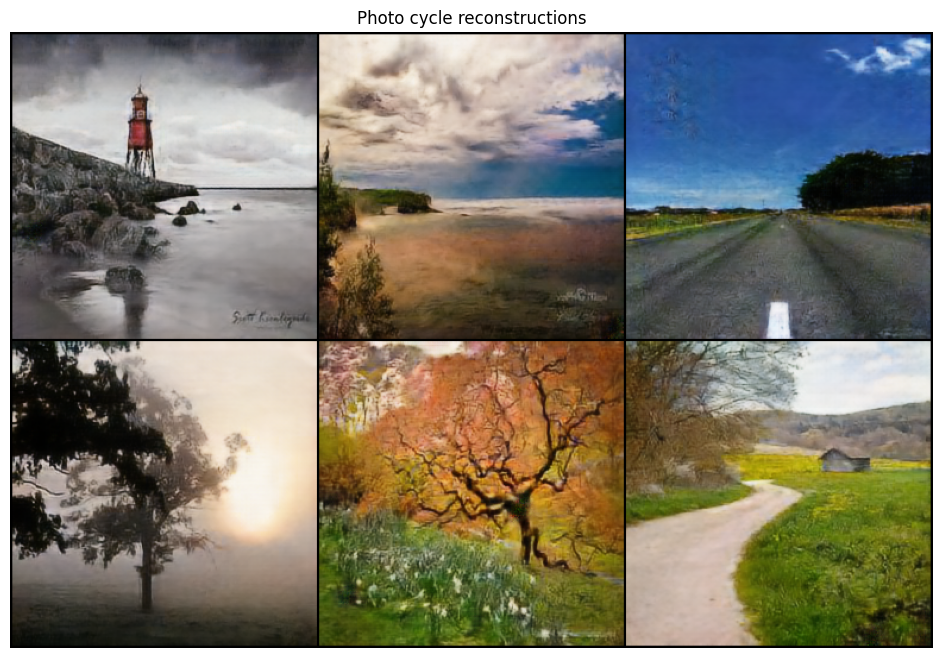

In [45]:
# Display generated samples

def show_image_grid(paths, title, n=6):
    images = []
    for path in list(paths)[:n]:
        with Image.open(path) as image:
            images.append(transforms.ToTensor()(image))
    grid = make_grid(images, nrow=3, padding=2)
    plt.figure(figsize=(12, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()

show_image_grid(validation_manifest["output_a2b"], "Monet to Photo")
show_image_grid(validation_manifest["output_b2a"], "Photo to Monet")
show_image_grid(validation_manifest["cycle_a"], "Monet cycle reconstructions")
show_image_grid(validation_manifest["cycle_b"], "Photo cycle reconstructions")

In [46]:
# Quantitative cycle reconstruction L1 and content preservation cosine similarity
#
# Computed per domain over each unique held out image. The paired
# validation_loader cycles the 30 Monet validation images about 23 times each,
# and unevenly since 703 is not a multiple of 30, so averaging over it weighted
# the Monet side numbers by that repetition rather than over the unique set.

@torch.no_grad()
def cycle_and_content_metrics(paths_a, paths_b, batch_size=8):
    G_A2B.eval(); G_B2A.eval()

    def run_domain(paths, forward, backward):
        loader = DataLoader(
            SingleDomainDataset(paths, validation_transform),
            batch_size=batch_size, shuffle=False, num_workers=0
        )
        l1_total = 0.0
        cosine_total = 0.0
        for images, _ in loader:
            real = images.to(DEVICE)
            translated = forward(real)
            reconstructed = backward(translated)
            # Summed per image, so the average does not depend on batch size or
            # on the final batch being smaller than the rest.
            l1_total += F.l1_loss(reconstructed, real, reduction="none").mean(dim=(1, 2, 3)).sum().item()
            # Content proxy: cosine similarity of downsampled normalized RGB.
            source_features = F.adaptive_avg_pool2d(real, (32, 32)).flatten(1)
            translated_features = F.adaptive_avg_pool2d(translated, (32, 32)).flatten(1)
            cosine_total += F.cosine_similarity(source_features, translated_features).sum().item()
        count = len(paths)
        return l1_total / count, cosine_total / count

    cycle_a, cosine_a2b = run_domain(paths_a, G_A2B, G_B2A)
    cycle_b, cosine_b2a = run_domain(paths_b, G_B2A, G_A2B)
    return {
        "cycle_reconstruction_l1_A": float(cycle_a),
        "cycle_reconstruction_l1_B": float(cycle_b),
        "content_cosine_A2B": float(cosine_a2b),
        "content_cosine_B2A": float(cosine_b2a),
        "cycle_n_images_A": len(paths_a),
        "cycle_n_images_B": len(paths_b)
    }


cycle_metrics = cycle_and_content_metrics(monet_val_images, photo_val_images)
print(json.dumps(cycle_metrics, indent=2))

{
  "cycle_reconstruction_l1_A": 0.16469806631406148,
  "cycle_reconstruction_l1_B": 0.09494782986376397,
  "content_cosine_A2B": 0.7348116715749105,
  "content_cosine_B2A": 0.8658340957391991,
  "cycle_n_images_A": 30,
  "cycle_n_images_B": 703
}


## 7. FID, KID, generative precision/recall, and LPIPS

These metrics are evaluation only. They do not affect training or generated submissions. Inception features are cached so evaluation is reproducible and does not repeatedly load the feature extractor.

In [47]:
# Evaluation feature extractor. This is never used for training or image generation.

from torchvision.models import inception_v3, Inception_V3_Weights

INCEPTION_DEVICE = DEVICE
inception_weights = Inception_V3_Weights.DEFAULT
inception_model = inception_v3(weights=inception_weights, transform_input=False, aux_logits=True)
inception_model.fc = nn.Identity()
inception_model.eval().to(INCEPTION_DEVICE)
for parameter in inception_model.parameters():
    parameter.requires_grad_(False)

inception_preprocess = inception_weights.transforms()
print("Evaluation-only Inception feature extractor loaded.")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:07<00:00, 13.8MB/s] 


Evaluation-only Inception feature extractor loaded.


In [ ]:
@torch.no_grad()
def extract_inception_features(image_paths, cache_name, max_images=None, cache=True):
    # Caching is opt in and used only for REAL images, whose features never
    # change. Caching generated images would silently return the previous
    # model's features after retraining or changing the seed.
    cache_path = METRIC_DIR / f"{cache_name}_inception_features.npy"
    if cache and cache_path.exists() and max_images is None:
        return np.load(cache_path)

    paths = list(image_paths)
    if max_images is not None:
        paths = paths[:max_images]
    features = []
    for start in tqdm(range(0, len(paths), 16), desc=f"Features {cache_name}"):
        images = []
        for path in paths[start:start+16]:
            with Image.open(path) as image:
                images.append(inception_preprocess(image.convert("RGB")))
        tensor = torch.stack(images).to(INCEPTION_DEVICE)
        output = inception_model(tensor)
        if isinstance(output, tuple):
            output = output[0]
        features.append(output.float().cpu().numpy())
    result = np.concatenate(features, axis=0)
    if cache and max_images is None:
        np.save(cache_path, result)
    return result


real_monet_features = extract_inception_features(monet_images, "real_monet")
real_photo_features = extract_inception_features(photo_images, "real_photo")

# From translate_paths, so each source image appears exactly once.
fake_photo_features = extract_inception_features(fake_photo_paths, "fake_photo", cache=False)
fake_monet_features = extract_inception_features(fake_monet_paths, "fake_monet", cache=False)

print("Real Monet / fake Monet features:", real_monet_features.shape, fake_monet_features.shape)
print("Real photo / fake photo features:", real_photo_features.shape, fake_photo_features.shape)

Features fake_monet:   7%|▋         | 3/44 [00:00<00:09,  4.41it/s]

In [ ]:
from scipy.linalg import sqrtm
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

def frechet_distance(features_a, features_b, eps=1e-6):
    """Frechet distance between two Gaussian fits of Inception features.

    The A2B direction has 30 generated images against 2048-dimensional
    features, so its covariance has rank at most 29 and is singular. sqrtm of
    a product of singular matrices can return values with a large imaginary
    component or non-finite entries, which would silently poison the result.
    A small ridge on the diagonal keeps the product positive definite, and the
    imaginary part is checked rather than discarded blindly.
    """
    mu_a, mu_b = features_a.mean(0), features_b.mean(0)
    sigma_a = np.cov(features_a, rowvar=False)
    sigma_b = np.cov(features_b, rowvar=False)

    offset = np.eye(sigma_a.shape[0]) * eps
    covariance_sqrt = sqrtm((sigma_a + offset) @ (sigma_b + offset))

    if not np.isfinite(covariance_sqrt).all():
        larger = np.eye(sigma_a.shape[0]) * (eps * 1000)
        covariance_sqrt = sqrtm((sigma_a + larger) @ (sigma_b + larger))
        print("WARNING: FID sqrtm needed a larger ridge; treat this value as unstable.")

    if np.iscomplexobj(covariance_sqrt):
        imaginary = np.max(np.abs(covariance_sqrt.imag))
        if imaginary > 1e-3:
            print(f"WARNING: FID sqrtm imaginary component {imaginary:.3e} is large; "
                  "the covariance estimate is poorly conditioned.")
        covariance_sqrt = covariance_sqrt.real

    return float(np.sum((mu_a - mu_b) ** 2) + np.trace(sigma_a + sigma_b - 2 * covariance_sqrt))


def polynomial_kernel(x, y):
    dimension = x.shape[1]
    return ((x @ y.T) / dimension + 1.0) ** 3


def kid_score(real_features, fake_features, subset_size=1000, n_subsets=50, seed=SEED):
    """Unbiased MMD^2 with a degree-3 polynomial kernel, averaged over subsets.

    Both sets were previously truncated to min(len(real), len(fake), 1000) by
    slicing from the front. For A2B that compared the 30 generated images
    against only the first 30 of 7038 real photos, making the score depend on
    an arbitrary ordering; for B2A it discarded 403 of 703 generated images.

    Random subsets are drawn instead, as the KID authors describe, and the
    standard deviation across subsets is returned so the reported value
    carries its own uncertainty.
    """
    rng = np.random.default_rng(seed)
    m = min(len(real_features), len(fake_features), subset_size)
    if m < 2:
        return float("nan"), float("nan")
    scores = []
    for _ in range(n_subsets):
        real = real_features[rng.choice(len(real_features), m, replace=False)]
        fake = fake_features[rng.choice(len(fake_features), m, replace=False)]
        k_rr = polynomial_kernel(real, real)
        k_ff = polynomial_kernel(fake, fake)
        k_rf = polynomial_kernel(real, fake)
        np.fill_diagonal(k_rr, 0)
        np.fill_diagonal(k_ff, 0)
        scores.append(k_rr.sum()/(m*(m-1)) + k_ff.sum()/(m*(m-1)) - 2*k_rf.mean())
    return float(np.mean(scores)), float(np.std(scores))


def density_coverage(real_features, fake_features, k=3):
    """Density and coverage, Naeem et al. (2020).

    Both are defined against each REAL sample's own k-nearest-neighbour
    radius. Two things were wrong before:

      * coverage compared real sample i's nearest-fake distance against fake
        sample i's radius. Those indices refer to unrelated samples, so the
        comparison was meaningless.
      * both sets were truncated to min(len(real), len(fake)), silently
        discarding most of the real reference set.
    """
    real = np.asarray(real_features)
    fake = np.asarray(fake_features)
    k_eff = max(1, min(k, len(real) - 1))

    real_nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(real)
    real_distances, _ = real_nn.kneighbors(real)
    real_radii = real_distances[:, -1]          # k-th neighbour, self excluded

    # (n_fake, n_real): does each fake fall inside each real sample's ball?
    inside = pairwise_distances(fake, real) <= real_radii[None, :]

    density = float(inside.sum(axis=1).mean() / k_eff)
    coverage = float(inside.any(axis=0).mean())
    return density, coverage


def calculate_fid_kid_pr(real_features, fake_features):
    density, coverage = density_coverage(real_features, fake_features)
    kid_mean, kid_std = kid_score(real_features, fake_features)
    return {
        "FID": frechet_distance(real_features, fake_features),
        "KID": kid_mean,
        "KID_std": kid_std,
        "n_real": int(len(real_features)),
        "n_fake": int(len(fake_features)),
        "generative_density": density,
        "generative_coverage": coverage
    }

evaluation_metrics = {}
evaluation_metrics.update({f"A2B_{k}": v for k, v in calculate_fid_kid_pr(real_photo_features, fake_photo_features).items()})
evaluation_metrics.update({f"B2A_{k}": v for k, v in calculate_fid_kid_pr(real_monet_features, fake_monet_features).items()})
evaluation_metrics.update(cycle_metrics)
print(json.dumps(evaluation_metrics, indent=2))

In [ ]:
# LPIPS evaluation. This is evaluation only and not used to train or generate images.

try:
    import lpips
    lpips_model = lpips.LPIPS(net="alex").to(DEVICE).eval()

    @torch.no_grad()
    def calculate_lpips(manifest):
        values_a, values_b = [], []
        for _, row in manifest.iterrows():
            input_a = validation_transform(Image.open(row["input_a"]).convert("RGB")).unsqueeze(0).to(DEVICE)
            input_b = validation_transform(Image.open(row["input_b"]).convert("RGB")).unsqueeze(0).to(DEVICE)
            fake_b = validation_transform(Image.open(row["output_a2b"]).convert("RGB")).unsqueeze(0).to(DEVICE)
            fake_a = validation_transform(Image.open(row["output_b2a"]).convert("RGB")).unsqueeze(0).to(DEVICE)
            values_a.append(lpips_model(input_a, fake_b).item())
            values_b.append(lpips_model(input_b, fake_a).item())
        return {"LPIPS_A2B": float(np.mean(values_a)), "LPIPS_B2A": float(np.mean(values_b))}

    evaluation_metrics.update(calculate_lpips(validation_manifest))
    print("LPIPS calculated.")
except Exception as exc:
    evaluation_metrics["LPIPS_status"] = f"Unavailable: {exc}"
    print("LPIPS unavailable:", exc)

In [ ]:
# Save all local evaluation metrics

evaluation_metrics["parameter_count_total"] = int(total_parameters)
evaluation_metrics["gpu_name"] = GPU_NAME
evaluation_metrics["total_training_time_seconds"] = float(total_training_time)
evaluation_metrics["peak_memory_gb_max"] = float(max(history["peak_memory_gb"]))
evaluation_metrics["mean_images_per_second"] = float(np.mean(history["images_per_second"]))
evaluation_metrics["nan_or_inf_total"] = int(sum(history["nan_or_inf_count"]))

with open(METRIC_DIR / "full_metrics_report.json", "w") as f:
    json.dump(evaluation_metrics, f, indent=2, default=str)
metrics_frame = pd.DataFrame([evaluation_metrics])
metrics_frame.to_csv(METRIC_DIR / "full_metrics_report.csv", index=False)
# The brief places this file at the member root, so write it there too.
metrics_frame.to_csv(MEMBER_ROOT / "full_metrics_report.csv", index=False)
print("Metrics written to:", METRIC_DIR / "full_metrics_report.csv")
print("                   ", MEMBER_ROOT / "full_metrics_report.csv")
print(json.dumps(evaluation_metrics, indent=2, default=str))

## 8. Fixed 30 sample human audit template

Ratings must be completed by two actual raters. This notebook does not fabricate human judgments. Each rater scores style transfer, content preservation, and artifacts from 1,5 for the same fixed 30 samples.

In [ ]:
audit_path = METRIC_DIR / "human_audit_30_samples.csv"
audit_rows = []
for index, row in validation_manifest.head(30).iterrows():
    audit_rows.append({
        "sample_id": int(index),
        "image_a2b": row["output_a2b"],
        "image_b2a": row["output_b2a"],
        "rater1_style": "", "rater1_content": "", "rater1_artifacts": "",
        "rater2_style": "", "rater2_content": "", "rater2_artifacts": ""
    })
pd.DataFrame(audit_rows).to_csv(audit_path, index=False)
print("Audit template saved to:", audit_path)
print("Fill this file using two independent raters before reporting human-audit results.")

In [ ]:
# Compute audit agreement after the two raters fill the CSV.

from sklearn.metrics import cohen_kappa_score

audit = pd.read_csv(audit_path)
rating_columns = [
    ("rater1_style", "rater2_style"),
    ("rater1_content", "rater2_content"),
    ("rater1_artifacts", "rater2_artifacts")
]

audit_results = {}
for first, second in rating_columns:
    valid = audit[[first, second]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(valid) == 30:
        audit_results[f"kappa_{first.replace('rater1_', '')}"] = float(cohen_kappa_score(valid[first], valid[second]))
        audit_results[f"agreement_{first.replace('rater1_', '')}"] = float((valid[first] == valid[second]).mean())
    else:
        audit_results["audit_status"] = "Incomplete: fill all 30 samples for both raters."

print(json.dumps(audit_results, indent=2))

## 9. Submission manifest

The exact Kaggle upload schema must match the instructor's competition instructions. The following manifest records only outputs generated directly by this trained model. Do not manually edit, replace, or hand-pick submitted images.

In [ ]:
# Generate a machine readable submission manifest from direct model outputs.

submission = validation_manifest[["index", "output_a2b", "output_b2a"]].copy()
submission["model_seed"] = SEED
submission["gpu_name"] = GPU_NAME
submission["checkpoint_source"] = str(CHECKPOINT_DIR)
submission.to_csv(OUTPUT_ROOT / "submission.csv", index=False)
print("Submission manifest saved to:", OUTPUT_ROOT / "submission.csv")
print("Confirm the instructor's Kaggle schema before uploading.")

## Final checklist

- Two unpaired image domains prepared.
- Two generators and two discriminators implemented from scratch.
- Adversarial, cycle-consistency, and identity losses used.
- 50-epoch training and linear learning-rate decay logged.
- Translations generated in both directions.
- Cycle-reconstruction checked.
- FID/KID computed in both directions.
- Density/coverage estimates computed.
- LPIPS computed when its evaluation dependency is available.
- Training curves, gradient norms, NaN/Inf count, time, images/sec, memory, and parameter count recorded.
- 30 sample human audit template created for two real raters.
- Kaggle submission manifest generated from model outputs.